<a href="https://colab.research.google.com/github/tekuugr-0205-16-hub/torch_tutorial/blob/main/myfrist_cnn_model_for_the_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data  import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid

import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
%matplotlib inline



In [3]:
transform = transforms.ToTensor()



In [4]:
train_data = datasets.MNIST(root='/cnn_data', train= True, download=True, transform= transform)

100%|██████████| 9.91M/9.91M [00:00<00:00, 15.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 358kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.31MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.07MB/s]


In [5]:
#test_data
test_data=  datasets.MNIST(root='/cnn_data', train= False, download=True, transform= transform)

In [6]:
train_data

Dataset MNIST
    Number of datapoints: 60000
    Root location: /cnn_data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [7]:
ls

sample_data/


In [8]:
pwd

'/content'

In [9]:
cd ../


/


In [10]:
pwd

'/'

In [11]:
ls

bin@                        home/    NGC-DL-CONTAINER-LICENSE  srv/
boot/                       kaggle/  opt/                      sys/
cnn_data/                   lib@     proc/                     tmp/
content/                    lib32@   python-apt/               tools/
cuda-keyring_1.1-1_all.deb  lib64@   python-apt.tar.xz*        usr/
datalab/                    libx32@  root/                     var/
dev/                        media/   run/
etc/                        mnt/     sbin@


In [12]:
cd cnn_data

/cnn_data


In [13]:
ls

MNIST/


In [14]:
pwd

'/cnn_data'

In [15]:
cd ../

/


In [16]:
#let start build the model of the cnn and pooling
train_loader= DataLoader(train_data, batch_size=10, shuffle=True)
test_loader= DataLoader(test_data, batch_size= 10 , shuffle= True)

In [17]:
class Cnn2_model(nn.Module):
  def __init__(self):
    super().__init__()
    self.conv1= nn.Conv2d(1,6,3,1)
    self.conv2 = nn.Conv2d(6,16,3,1)
    self.maxpool1= nn.MaxPool2d(2,2)


    self. fcl = nn.Linear(5*5*16, 120)
    self.fc2= nn.Linear(120,84)
    self.fc3= nn.Linear(84,10)

  def forward(self,x):
    x = F.relu(self.conv1(x))
    x = self.maxpool1(x)

    x = F.relu(self.conv2(x))
    x = self.maxpool1(x)

    #for the flatten the data
    x =x.view(-1,5*5*16)
    #now for the fully connected layer

    x = F.relu(self.fcl(x))
    x = F.relu(self.fc2(x))
    x = self.fc3(x)
    return F.log_softmax(x, dim=1)









In [18]:
torch.manual_seed(42)
cnn_model = Cnn2_model()
cnn_model


Cnn2_model(
  (conv1): Conv2d(1, 6, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(3, 3), stride=(1, 1))
  (maxpool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fcl): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

In [19]:
#let create the loss and otimizer function for the model
loss_fn = nn.CrossEntropyLoss()
 #and
optimizer = torch.optim.Adam(cnn_model.parameters(), lr=0.001)

In [23]:
import time
start_time = time.time()
# let create the variable  to track things
epochs = 5
train_losses = []
test_losses = []
train_correct = []
test_correct = []





#for loop od epoochs

for i in range(epochs):
  trn_corr = 0
  tst_corr = 0

  cnn_model.train()
  for batch,(x_train, y_train) in enumerate(train_loader):
    batch +=1
    y_pred = cnn_model(x_train)

    loss = loss_fn(y_pred, y_train)
    #let

    predicted = torch.max(y_pred.data, 1)[1]
    batch_correct= (predicted == y_train).sum()
    trn_corr += batch_correct


    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if batch % 600 == 0:
      print(f'epoch: {i} \t {batch} loss: {loss.item()}')

  train_losses.append(loss)
  train_correct.append(trn_corr)
  #test
  with torch.no_grad():
    cnn_model.eval()
    for batch,(x_test, y_test) in enumerate(test_loader):
      y_val = cnn_model(x_test)

      predicted = torch.max(y_val.data, 1)[1]


      tst_corr += (predicted == y_test).sum()
  loss = loss_fn(y_val, y_test)
  test_losses.append(loss)
  test_correct.append(tst_corr)



current_time = time.time()
total_time = current_time - start_time
print(f"Training took: {total_time/60} minutes!")

epoch: 0 	 600 loss: 0.44003671407699585
epoch: 0 	 1200 loss: 0.2105361670255661
epoch: 0 	 1800 loss: 0.015581294894218445
epoch: 0 	 2400 loss: 0.35302668809890747
epoch: 0 	 3000 loss: 0.30267852544784546
epoch: 0 	 3600 loss: 0.02708793617784977
epoch: 0 	 4200 loss: 0.0019023455679416656
epoch: 0 	 4800 loss: 0.010783380828797817
epoch: 0 	 5400 loss: 0.30589109659194946
epoch: 0 	 6000 loss: 0.006145596504211426
epoch: 1 	 600 loss: 0.004767468199133873
epoch: 1 	 1200 loss: 0.05294457823038101
epoch: 1 	 1800 loss: 0.08789493143558502
epoch: 1 	 2400 loss: 0.01950441487133503
epoch: 1 	 3000 loss: 0.025554731488227844
epoch: 1 	 3600 loss: 0.014240291900932789
epoch: 1 	 4200 loss: 0.24967996776103973
epoch: 1 	 4800 loss: 0.05962792783975601
epoch: 1 	 5400 loss: 0.517756998538971
epoch: 1 	 6000 loss: 0.0009094128618016839
epoch: 2 	 600 loss: 0.01314087025821209
epoch: 2 	 1200 loss: 0.012580555863678455
epoch: 2 	 1800 loss: 0.02032151259481907
epoch: 2 	 2400 loss: 0.23808

/tmp/ipykernel_1687/2606647213.py:5: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  plt.plot(torch.tensor(train_losses).detach().numpy(), label='training loss')


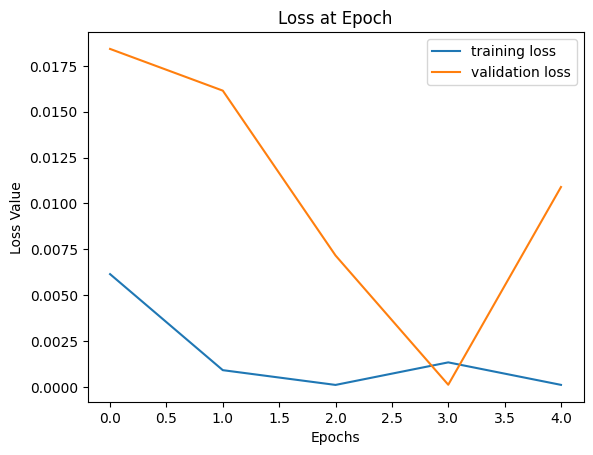

In [26]:
import matplotlib.pyplot as plt
import torch

# If train_losses is a list of tensors, we convert it to a single tensor first
plt.plot(torch.tensor(train_losses).detach().numpy(), label='training loss')

# Fixed the .numpy() and the variable name logic
plt.plot(torch.tensor(test_losses).detach().numpy(), label='validation loss')

plt.title("Loss at Epoch")
plt.xlabel("Epochs")
plt.ylabel("Loss Value")
plt.legend()
plt.show() # Don't forget this to actually pop up the window!

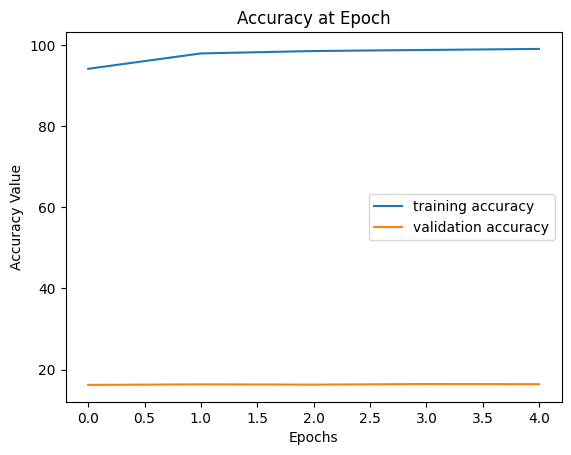

In [29]:
plt.plot([t/600 for t in train_correct], label='training accuracy')
plt.plot([t/600 for t in test_correct], label='validation accuracy' )
plt.title("Accuracy at Epoch")
plt.xlabel("Epochs")
plt.ylabel("Accuracy Value")
plt.legend()

In [32]:
test_load_everything = DataLoader(test_data, batch_size = 1000, shuffle=False)
correct = 0
for x_test,y_test in test_load_everything:
  y_val = cnn_model(x_test)
  predicted = torch.max(y_val.data, 1)[1]
  correct += (predicted == y_test).sum()
  loss = loss_fn(y_val, y_test)



In [33]:
correct.item()/len(test_data)*100
loss

tensor(0.0477, grad_fn=<NllLossBackward0>)